In [96]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scienceplots
from itertools import count, islice
plt.style.use(["science"])

f(x) = sinx sinhx
f(x) = x - sinx
f(x) = xcosx
stop when f(x)< 10^-8

In [97]:
from itertools import count, islice

def fib_gen():
    a, b = 0, 1
    while True:
        a, b = b, a + b
        yield a

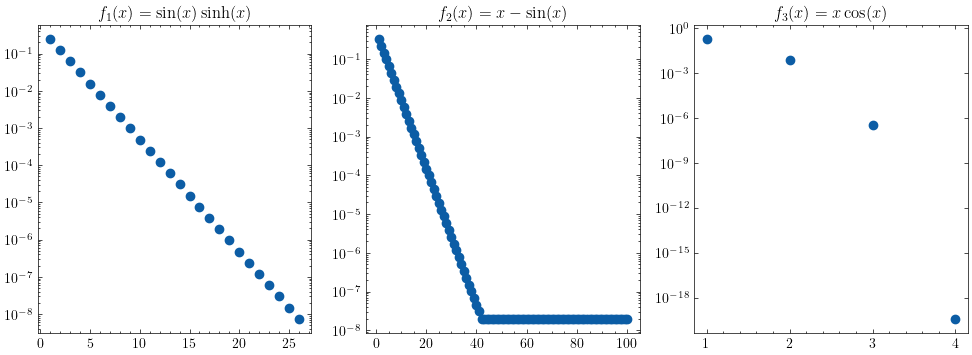

In [98]:
def f1_gen(tol=1e-8, max_iter=100):
    a = 0.5
    for _ in range(max_iter):
        a = a - (np.sin(a) * np.sinh(a))/(
            (np.sin(a) * np.cosh(a))+ (np.cos(a) * np.sinh(a))
            )
        yield a

        if abs(a) < tol:
            break
def f2_gen(tol=1e-8, max_iter=100):
    a = 0.5
    for _ in range(max_iter):
        a = a - (a - np.sin(a))/(
            (1 - np.cos(a))
            )
        yield a

        if abs(a) < tol:
            break
def f3_gen(tol=1e-8, max_iter=100):
    a = 0.5
    for _ in range(max_iter):
        a = a - (a * np.cos(a))/(
            (np.cos(a) + a * -np.sin(a))
            )
        yield a

        if abs(a) < tol:
            break
                              
seq = [
    np.array(list(f1_gen()), dtype=np.float64),
    np.array(list(f2_gen()), dtype=np.float64),
    np.array(list(f3_gen()), dtype=np.float64),
]

titles = [
    r"$f_1(x)=\sin(x)\sinh(x)$",
    r"$f_2(x)=x-\sin(x)$",
    r"$f_3(x)=x\cos(x)$",
]
n_vals = [
    np.arange(1, len(seq[0])+1, dtype=np.float64),
    np.arange(1, len(seq[1])+1, dtype=np.float64),
    np.arange(1, len(seq[2])+1, dtype=np.float64),
]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for i in range(0,3):

    ax[i].plot(n_vals[i], np.abs(seq[i]), "o")
    ax[i].set_yscale("log")
    ax[i].set_title(titles[i])
plt.show()
